<div dir=rtl style="text-align: right">

# שיעור 1 — מה זה רשת נוירונים ו-SGD?

## הרעיון המרכזי

רשת נוירונים היא בסך הכל **פונקציה עם פרמטרים** — כמו משפחה של עקומות.  
המטרה: למצוא את הפרמטרים שגורמים לפונקציה **להתאים הכי טוב לנתונים**.

בשיעור זה נדגים את הרעיון הזה בדוגמה פשוטה ומוחשית:  
**נחפש את הפרבולה שמתאימה ביותר לקבוצת נקודות.**

---

## המשפחה שלנו

$$f(x) = ax^2 + bx - 2$$

הפרמטרים הם $a$ ו-$b$. הקבוע $-2$ קבוע מראש.  
השאלה: **אילו $a, b$ מתאימים הכי טוב לנתונים?**

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13

<div dir=rtl style="text-align: right">

## שלב 1 — יצירת הנתונים

נגריל פרבולה אמיתית עם מקדמים $a^*, b^*$ אקראיים, ניצור 100 נקודות לאורכה, ונוסיף רעש גאוסיאני.

</div>

In [ ]:
np.random.seed(42)

# הפרבולה ה"אמיתית"
a_true = np.random.uniform(-1.5, 1.5)
b_true = np.random.uniform(-3, 3)
c_true = -2  # קבוע

print(f"פרבולה אמיתית: f(x) = {a_true:.3f}·x² + {b_true:.3f}·x - 2")

# 100 נקודות
x = np.linspace(-5, 5, 100)
noise = np.random.normal(0, 1.5, size=100)
y = a_true * x**2 + b_true * x + c_true + noise

h = lambda s: s[::-1]  # עברית ב-matplotlib — הפוך את המחרוזת

plt.scatter(x, y, color='steelblue', alpha=0.6, s=25, label=h('נקודות עם רעש'))
x_plot = np.linspace(-5, 5, 300)
plt.plot(x_plot, a_true * x_plot**2 + b_true * x_plot + c_true,
         'k--', linewidth=1.5, label=h('פרבולה אמיתית'))
plt.legend()
plt.title(h('הנתונים שלנו'))
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## שלב 2 — פונקציית ה-Loss

איך נמדוד כמה טובה פרבולה מסוימת?  
**סכום ריבועי המרחקים האנכיים** בין כל נקודה לבין הפרבולה:

$$L(a, b) = \sum_{i=1}^{N} \left( y_i - f(x_i) \right)^2 = \sum_{i=1}^{N} \left( y_i - ax_i^2 - bx_i + 2 \right)^2$$

ככל ש-$L$ קטן יותר — הפרבולה מתאימה טוב יותר.

</div>

In [3]:
def loss(a, b, x, y):
    """סכום ריבועי השגיאות"""
    predictions = a * x**2 + b * x - 2
    return np.sum((y - predictions)**2)

# בואו נראה את ה-loss של הפרבולה האמיתית לעומת פרבולה שרירותית
print(f"Loss של הפרבולה האמיתית:     {loss(a_true, b_true, x, y):.1f}")
print(f"Loss של הפרבולה a=0, b=0:    {loss(0, 0, x, y):.1f}")
print(f"Loss של הפרבולה a=1, b=1:    {loss(1, 1, x, y):.1f}")

Loss של הפרבולה האמיתית:     190.5
Loss של הפרבולה a=0, b=0:    8423.8
Loss של הפרבולה a=1, b=1:    27772.6


<div dir=rtl style="text-align: right">

## שלב 3 — נוף ה-Loss

ה-Loss הוא פונקציה של $a$ ו-$b$. בואו נצייר אותו ונראה איך הוא נראה.

אנחנו מחפשים את **השפל** — הנקודה עם ה-Loss הנמוך ביותר.

</div>

In [ ]:
# רשת של ערכי a, b — מורחבת כדי לכלול את כל מסלול ה-GD
a_range = np.linspace(a_true - 2, a_true + 4, 200)
b_range = np.linspace(b_true - 8, b_true + 4, 200)
A, B = np.meshgrid(a_range, b_range)

# חישוב loss לכל צירוף
L = np.array([[loss(a, b, x, y) for a in a_range] for b in b_range])

plt.figure(figsize=(8, 6))
cp = plt.contourf(A, B, L, levels=40, cmap='RdYlGn_r')
plt.colorbar(cp, label='Loss')
plt.scatter([a_true], [b_true], color='black', s=120, zorder=5,
            marker='*', label=h('פרמטרי יצירת הדאטה') + f' ({a_true:.2f}, {b_true:.2f})')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Loss Landscape — ' + h('מחפשים את השפל'))
plt.legend()
plt.show()

<div dir=rtl style="text-align: right">

## שלב 4 — גרדיאנט: לאן "יורד" ה-Loss?

הגרדיאנט $\nabla L$ הוא הוקטור שמצביע לכיוון **העלייה התלולה ביותר**.  
לכן נצעד **נגד** הגרדיאנט.

נגזור אנליטית:

$$\frac{\partial L}{\partial a} = -2 \sum_i (y_i - f(x_i)) \cdot x_i^2$$

$$\frac{\partial L}{\partial b} = -2 \sum_i (y_i - f(x_i)) \cdot x_i$$

</div>

In [5]:
def gradients(a, b, x, y):
    """נגזרות חלקיות של ה-loss לפי a ו-b"""
    residuals = y - (a * x**2 + b * x - 2)  # השגיאות
    dL_da = -2 * np.sum(residuals * x**2)
    dL_db = -2 * np.sum(residuals * x)
    return dL_da, dL_db

<div dir=rtl style="text-align: right">

## שלב 5 — Gradient Descent

האלגוריתם פשוט:

$$a \leftarrow a - \eta \cdot \frac{\partial L}{\partial a}$$
$$b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

כאשר $\eta$ (eta) הוא **קצב הלמידה** — גודל הצעד.

</div>

In [6]:
# נקודת פתיחה — פינה רחוקה מהאופטימום (loss גבוה מאוד)
a = a_true + 3.5
b = b_true - 7.5
lr = 1e-5
n_steps = 5000

# שמירת ההיסטוריה
history_a = [a]
history_b = [b]
history_loss = [loss(a, b, x, y)]

for step in range(n_steps):
    da, db = gradients(a, b, x, y)
    a -= lr * da
    b -= lr * db
    history_a.append(a)
    history_b.append(b)
    history_loss.append(loss(a, b, x, y))

print(f"פרמטרים אמיתיים:  a={a_true:.4f}, b={b_true:.4f}")
print(f"פרמטרים שנמצאו:   a={a:.4f}, b={b:.4f}")
print(f"Loss התחלתי: {history_loss[0]:.0f}")
print(f"Loss סופי:   {history_loss[-1]:.1f}")

פרמטרים אמיתיים:  a=-0.3764, b=2.7043
פרמטרים שנמצאו:   a=-0.3885, b=2.7160
Loss התחלתי: 208622
Loss סופי:   188.4


<div dir=rtl style="text-align: right">

## שלב 6 — גרף ה-Loss לאורך הלמידה

</div>

In [ ]:
plt.plot(history_loss, color='crimson')
plt.xlabel(h('צעד'))
plt.ylabel('Loss')
plt.title('Loss ' + h('במהלך האופטימיזציה'))
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## שלב 7 — Gradient Descent אינטראקטיבי

עכשיו נצעד **ידנית** לעבר השפל.

- לחצו **▶ צעד הבא** כדי לבצע צעד אחד בכיוון הגרדיאנט
- **החץ הכחול** מראה את כיוון הצעד הבא, ועליו מסומן גודל הצעד: $\eta \times |\nabla L|$
- שנו את **Learning Rate** וראו כיצד גודל הצעדים משתנה בזמן אמת

</div>

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ─── עזר: עברית ב-matplotlib חייבת הפיכה (matplotlib מציג LTR) ──
h = lambda s: s[::-1]

# ─── מצב התחלתי ────────────────────────────────────────────────
_a0 = a_true + 3.5
_b0 = b_true - 7.5
state = {
    'a': _a0, 'b': _b0,
    'hist_a': [_a0], 'hist_b': [_b0],
    'lr': 1e-5,
}

ZOOM = 2.0  # רדיוס החלון סביב המיקום הנוכחי (ביחידות פרמטרים)

# ─── פונקציית ציור ───────────────────────────────────────────────
def redraw():
    fig, ax = plt.subplots(figsize=(7, 7))

    ha, hb = state['hist_a'], state['hist_b']
    a_cur, b_cur = state['a'], state['b']
    lr = state['lr']

    # זום על המיקום הנוכחי
    ax.set_xlim(a_cur - ZOOM, a_cur + ZOOM)
    ax.set_ylim(b_cur - ZOOM, b_cur + ZOOM)
    ax.set_aspect('equal')

    # רקע — contour
    ax.contourf(A, B, L, levels=40, cmap='RdYlGn_r', alpha=0.85)
    ax.contour(A, B, L, levels=20, colors='white', alpha=0.2, linewidths=0.6)

    # מסלול עד כה — כהה
    if len(ha) > 1:
        ax.plot(ha, hb, color='#111111', linewidth=1.8, alpha=0.9)

    # נקודת פתיחה (רק אם בתוך החלון)
    if abs(ha[0] - a_cur) < ZOOM * 1.5 and abs(hb[0] - b_cur) < ZOOM * 1.5:
        ax.scatter(ha[0], hb[0], color='white', s=80, zorder=5,
                   label=h('נקודת פתיחה'))

    # פרמטרים אמיתיים (רק אם בתוך החלון)
    if abs(a_true - a_cur) < ZOOM and abs(b_true - b_cur) < ZOOM:
        ax.scatter([a_true], [b_true], color='black', s=160, marker='*', zorder=7,
                   label=h('פרמטרים אמיתיים') + f' ({a_true:.2f}, {b_true:.2f})')

    # מיקום נוכחי
    ax.scatter(a_cur, b_cur, color='deeppink', s=150, zorder=6,
               label=h('מיקום נוכחי'))

    # ─── חץ הגרדיאנט ────────────────────────────────────────────
    da, db = gradients(a_cur, b_cur, x, y)
    step_a = -lr * da
    step_b = -lr * db
    step_mag = np.sqrt(step_a**2 + step_b**2)

    if step_mag > 1e-12:
        ax.annotate(
            '',
            xy=(a_cur + step_a, b_cur + step_b),
            xytext=(a_cur, b_cur),
            arrowprops=dict(
                arrowstyle='->', color='cyan', lw=3,
                mutation_scale=22, shrinkA=0, shrinkB=0
            ),
            zorder=9
        )

    n = len(ha) - 1
    cur_loss = loss(a_cur, b_cur, x, y)
    ax.set_title(
        f'Step {n}  |  Loss = {cur_loss:.1f}  |  lr = {lr:.2e}  |  step size = {step_mag:.4f}',
        fontsize=10)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()

    with out:
        out.clear_output(wait=True)
        display(fig)
    plt.close(fig)

# ─── ווידג'טים ──────────────────────────────────────────────────
out = widgets.Output()

btn_next = widgets.Button(
    description='▶ צעד הבא', button_style='primary',
    layout=widgets.Layout(width='130px', height='36px'))
btn_next10 = widgets.Button(
    description='⏩ ×10 צעדים', button_style='info',
    layout=widgets.Layout(width='150px', height='36px'))
btn_reset = widgets.Button(
    description='↺ אתחול', button_style='warning',
    layout=widgets.Layout(width='100px', height='36px'))
lr_slider = widgets.FloatLogSlider(
    value=1e-5, base=10, min=-7, max=-3, step=0.25,
    description='Learning Rate:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='430px'))
lr_label = widgets.HTML(
    value=f'<b style="font-family:monospace">lr = {1e-5:.2e}</b>')

def do_step():
    da, db = gradients(state['a'], state['b'], x, y)
    state['a'] -= state['lr'] * da
    state['b'] -= state['lr'] * db
    state['hist_a'].append(state['a'])
    state['hist_b'].append(state['b'])

def on_next(_):
    do_step(); redraw()

def on_next10(_):
    for _ in range(10): do_step()
    redraw()

def on_reset(_):
    state['a'] = _a0; state['b'] = _b0
    state['hist_a'] = [_a0]; state['hist_b'] = [_b0]
    redraw()

def on_lr_change(change):
    state['lr'] = change['new']
    lr_label.value = f'<b style="font-family:monospace">lr = {change["new"]:.2e}</b>'
    redraw()

btn_next.on_click(on_next)
btn_next10.on_click(on_next10)
btn_reset.on_click(on_reset)
lr_slider.observe(on_lr_change, names='value')

controls = widgets.HBox(
    [btn_next, btn_next10, btn_reset, lr_slider, lr_label],
    layout=widgets.Layout(gap='10px', align_items='center', flex_wrap='wrap'))
display(widgets.VBox([controls, out], layout=widgets.Layout(gap='8px')))
redraw()

<div dir=rtl style="text-align: right">

## שלב 7.5 — המסלול בתלת-ממד

עכשיו נראה את אותו מסלול, אבל על **המשטח עצמו** — ה-Loss כציר Z.  
ניתן לראות בבירור איך האלגוריתם "מחליק במדרון" לעבר השפל.

> **שימו לב:** הנקודה השחורה (◆) מסמנת את **פרמטרי יצירת הדאטה** — הערכים שבהם השתמשנו לייצר את הנקודות.  
> היא אינה בהכרח בשפל ה-Loss, מכיוון שהרעש שהוספנו "מזיז" את המינימום קצת.  
> GD מוצא את הפרמטרים שמתאימים **לנתונים שקיבל** — לא את הפרמטרים ה"אמיתיים" של הפרבולה המקורית.

</div>

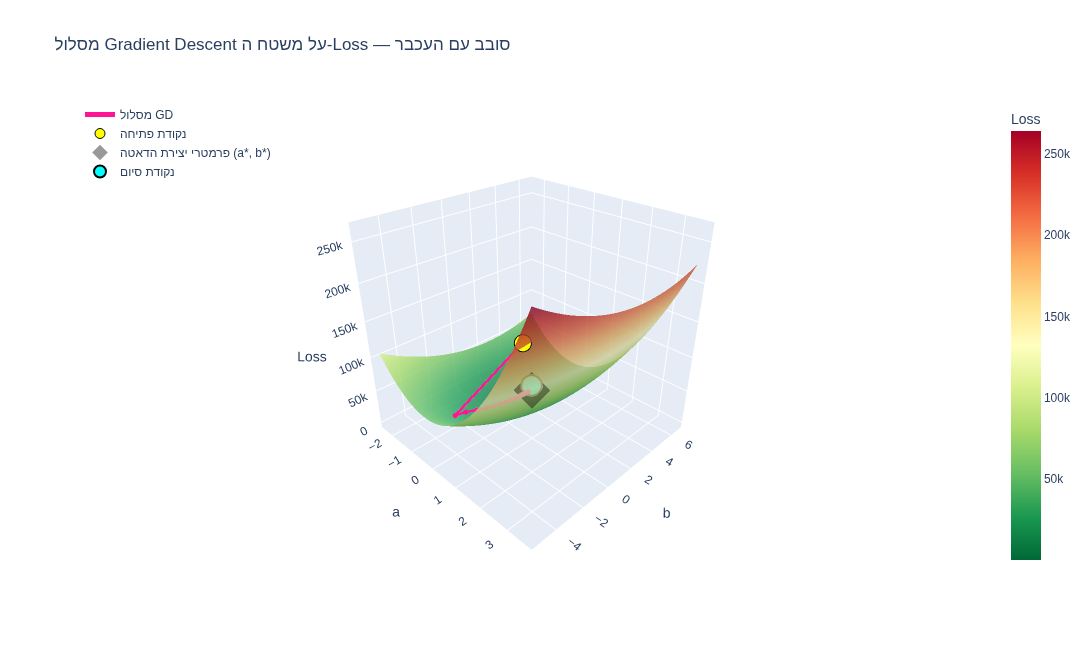

In [9]:
import plotly.graph_objects as go

# חישוב Loss לכל נקודה במסלול
path_loss = [loss(ha, hb, x, y) for ha, hb in zip(history_a, history_b)]

# דגימה כל 10 צעדים (5000 צעדים → 500 נקודות)
step = 10
ha = history_a[::step]
hb = history_b[::step]
hl = path_loss[::step]

# offset כדי שהנקודות יצופו מעל המשטח
z_offset = (L.max() - L.min()) * 0.03

fig = go.Figure()

# משטח ה-Loss
fig.add_trace(go.Surface(
    x=A, y=B, z=L,
    colorscale='RdYlGn',
    reversescale=True,
    opacity=0.8,
    showscale=True,
    colorbar=dict(title='Loss'),
    name='Loss surface'
))

# מסלול GD
fig.add_trace(go.Scatter3d(
    x=ha, y=hb, z=[v + z_offset for v in hl],
    mode='lines+markers',
    line=dict(color='deeppink', width=5),
    marker=dict(size=3, color='deeppink'),
    name='מסלול GD'
))

# נקודת פתיחה
fig.add_trace(go.Scatter3d(
    x=[history_a[0]], y=[history_b[0]], z=[path_loss[0] + z_offset],
    mode='markers',
    marker=dict(size=10, color='yellow', symbol='circle', line=dict(color='black', width=1)),
    name='נקודת פתיחה'
))

# פרמטרי יצירת הדאטה — חצי שקוף
fig.add_trace(go.Scatter3d(
    x=[a_true], y=[b_true], z=[loss(a_true, b_true, x, y) + z_offset],
    mode='markers',
    marker=dict(size=12, color='black', symbol='diamond', opacity=0.4),
    name='פרמטרי יצירת הדאטה (a*, b*)'
))

# נקודת סיום — מעל הכל
fig.add_trace(go.Scatter3d(
    x=[history_a[-1]], y=[history_b[-1]], z=[path_loss[-1] + z_offset * 2],
    mode='markers',
    marker=dict(size=12, color='cyan', symbol='circle', line=dict(color='black', width=2)),
    name='נקודת סיום'
))

fig.update_layout(
    title='מסלול Gradient Descent על משטח ה-Loss — סובב עם העכבר',
    scene=dict(
        xaxis_title='a',
        yaxis_title='b',
        zaxis_title='Loss',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2))
    ),
    width=900,
    height=650,
    legend=dict(x=0, y=1)
)

fig.show()

<div dir=rtl style="text-align: right">

## שלב 8 — הפרבולה שנמצאה מול הנקודות

</div>

In [ ]:
plt.scatter(x, y, color='steelblue', alpha=0.6, s=25, label=h('נקודות'))

x_plot = np.linspace(-5, 5, 300)
plt.plot(x_plot, a_true * x_plot**2 + b_true * x_plot - 2,
         'k--', linewidth=2, label=h('פרבולה אמיתית') + f' (a={a_true:.2f}, b={b_true:.2f})')
plt.plot(x_plot, a * x_plot**2 + b * x_plot - 2,
         'crimson', linewidth=2, label=h('פרבולה שנמצאה') + f' (a={a:.2f}, b={b:.2f})')

plt.legend()
plt.title(h('תוצאה סופית'))
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## ניסוי — שחקו עם הפרמטרים

שנו את הערכים הבאים ובדקו מה קורה:

| פרמטר | מה לנסות |
|--------|----------|
| `lr` | נסו `1e-4` — מה קורה? נסו `1e-7` — כמה צעדים צריך? |
| `n_steps` | מה קורה עם 50 צעדים? עם 2000? |
| `a, b` (נקודת פתיחה) | נסו `a=5, b=-5` — האם מגיעים לאותו מקום? |
| `noise` | שנו את `1.5` ל-`0` או ל-`5` — מה ה-loss הסופי? |

</div>

<div dir=rtl style="text-align: right">

---

## סיכום

| מושג | בדוגמה שלנו | ברשת נוירונים |
|------|-------------|----------------|
| **פונקציה עם פרמטרים** | $f(x)=ax^2+bx-2$ | שכבות עם משקולות |
| **נתוני אימון** | 100 נקודות $(x_i, y_i)$ | אלפי/מיליוני דוגמאות |
| **Loss** | סכום ריבועי שגיאות | Cross-entropy, MSE, ... |
| **פרמטרים** | $a, b$ (2 פרמטרים) | מיליוני משקולות |
| **אופטימיזציה** | Gradient Descent | SGD, Adam, ... |

**הרעיון זהה לחלוטין** — רק הסדר של גדלות שונה.

</div>